# **1. Perkenalan Dataset**

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

**Dataset yang digunakan pada eksperimen ini:**

| Keterangan | Detail |
|---|---|
| Nama dataset | Pima Indians Diabetes Database |
| Sumber | Kaggle - https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database |
| Lisensi | CC0: Public Domain (UCI ML Repository) |
| Jumlah baris | 768 |
| Jumlah kolom | 9 (8 fitur numerik + 1 target) |
| Format | CSV (`diabetes_raw.csv`) |
| Tipe masalah | Klasifikasi biner (prediksi diabetes) |

**Deskripsi fitur:**

| Kolom | Deskripsi |
|---|---|
| Pregnancies | Jumlah kehamilan |
| Glucose | Konsentrasi glukosa plasma (2 jam, tes toleransi oral) |
| BloodPressure | Tekanan darah diastolik (mm Hg) |
| SkinThickness | Ketebalan lipatan kulit trisep (mm) |
| Insulin | Insulin serum 2 jam (mu U/ml) |
| BMI | Body Mass Index (kg/m^2) |
| DiabetesPedigreeFunction | Skor riwayat diabetes keluarga |
| Age | Umur (tahun) |
| Outcome | Target: 1 = diabetes, 0 = tidak diabetes |

**Tujuan eksperimen:** memahami karakteristik data (EDA) dan menghasilkan dataset
siap-latih melalui preprocessing. Hasilnya kemudian dikonversi menjadi
`preprocessing/automate_Andi-Sakta.py` dan dijalankan otomatis lewat GitHub Actions.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')
%matplotlib inline

print('pandas :', pd.__version__)
print('numpy  :', np.__version__)
print('seaborn:', sns.__version__)


pandas : 2.3.3
numpy  : 2.5.3
seaborn: 0.13.2


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Dataset mentah disimpan di root repo: diabetes_raw.csv
df = pd.read_csv('../diabetes_raw.csv')

print('Shape dataset:', df.shape)
df.head()


Shape dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Cek tipe data & konsistensi hasil pemuatan
print(df.dtypes)
print()
print('Jumlah data duplikat:', df.duplicated().sum())
print('Jumlah nilai kosong (NaN):', int(df.isnull().sum().sum()))


Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Jumlah data duplikat: 0
Jumlah nilai kosong (NaN): 0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
# 4.1 Struktur & statistik deskriptif
df.info()
df.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


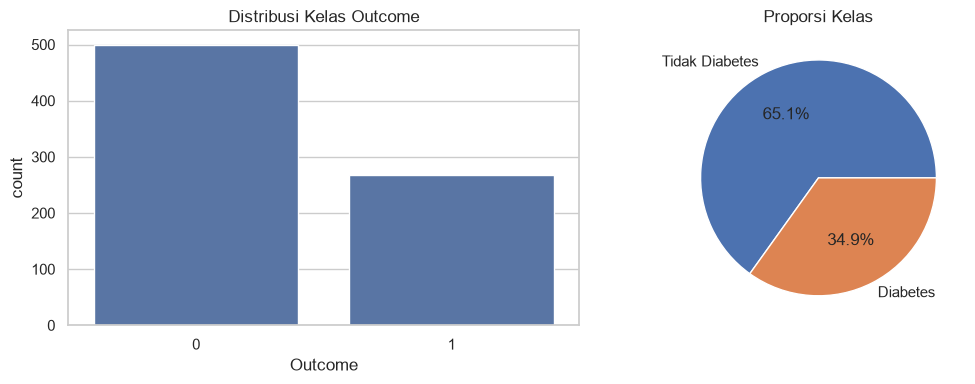

Outcome
0    500
1    268
Name: count, dtype: int64

Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


In [5]:
# 4.2 Distribusi target (Outcome)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='Outcome', data=df, ax=ax[0])
ax[0].set_title('Distribusi Kelas Outcome')

df['Outcome'].value_counts().plot.pie(
    autopct='%1.1f%%', labels=['Tidak Diabetes', 'Diabetes'], ax=ax[1], ylabel=''
)
ax[1].set_title('Proporsi Kelas')
plt.tight_layout()
plt.show()

print(df['Outcome'].value_counts())
print()
print(df['Outcome'].value_counts(normalize=True).round(4))


In [6]:
# 4.3 Deteksi nilai 0 yang tidak valid secara medis
# Glucose, BloodPressure, SkinThickness, Insulin, BMI tidak mungkin bernilai 0
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_report = pd.DataFrame({
    'jumlah_nol': [(df[c] == 0).sum() for c in cols_with_zero],
    'persen': [round((df[c] == 0).mean() * 100, 2) for c in cols_with_zero],
}, index=cols_with_zero)
zero_report


,jumlah_nol,persen
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43


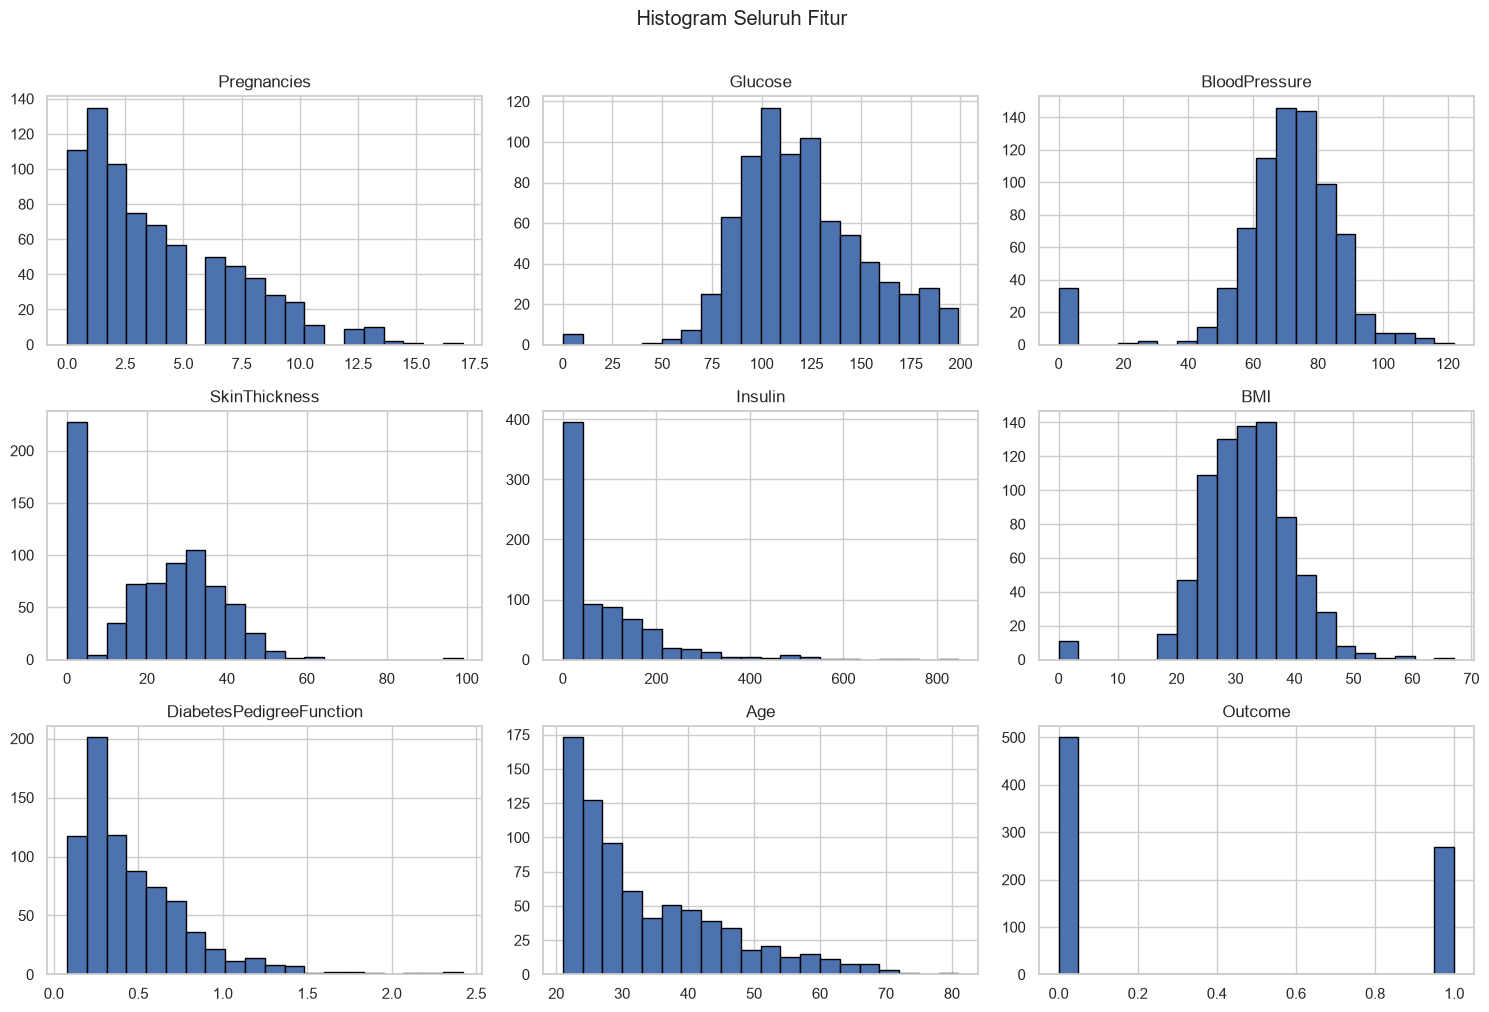

In [7]:
# 4.4 Distribusi setiap fitur
df.hist(bins=20, figsize=(15, 10), edgecolor='black')
plt.suptitle('Histogram Seluruh Fitur', y=1.01)
plt.tight_layout()
plt.show()


C:\Users\HP ID\AppData\Local\Temp\ipykernel_26444\1031791756.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30)


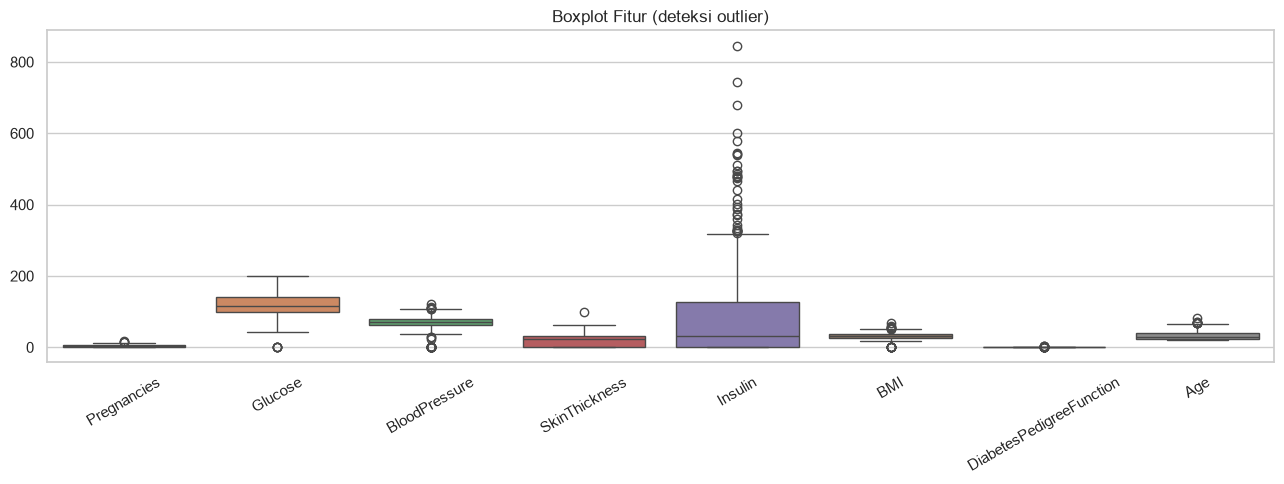

In [8]:
# 4.5 Deteksi outlier dengan boxplot
fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df.drop(columns=['Outcome']), ax=ax)
ax.set_title('Boxplot Fitur (deteksi outlier)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
plt.tight_layout()
plt.show()


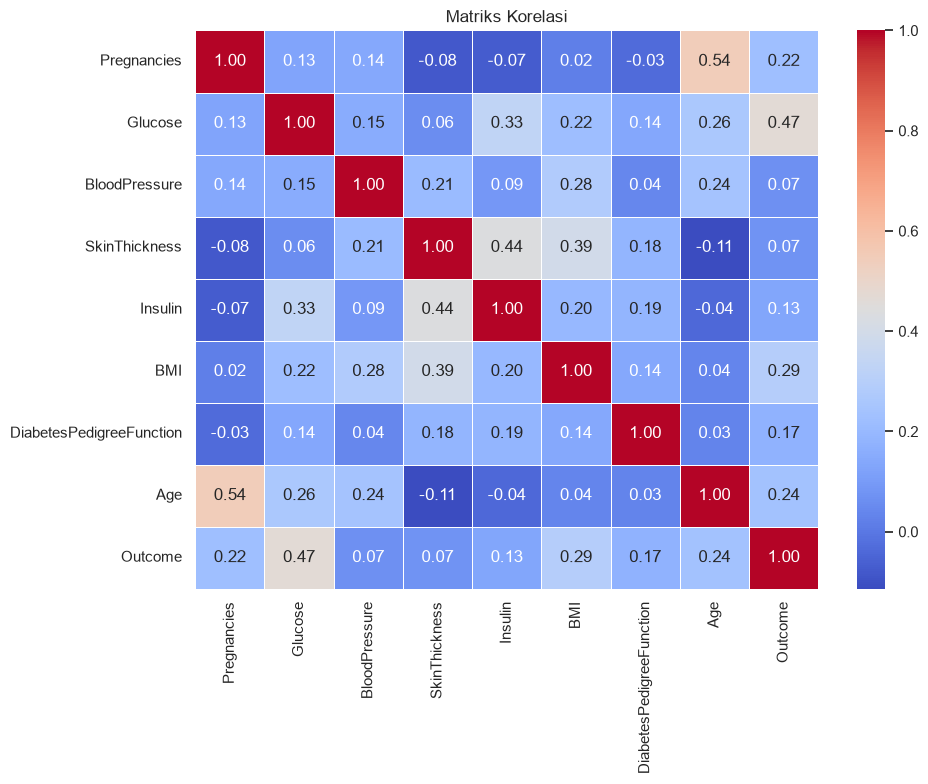

Korelasi terhadap Outcome (urut):
Glucose                     0.4666
BMI                         0.2927
Age                         0.2384
Pregnancies                 0.2219
DiabetesPedigreeFunction    0.1738
Insulin                     0.1305
SkinThickness               0.0748
BloodPressure               0.0651
Name: Outcome, dtype: float64


In [9]:
# 4.6 Korelasi antar fitur terhadap target
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi')
plt.tight_layout()
plt.show()

print('Korelasi terhadap Outcome (urut):')
print(df.corr()['Outcome'].drop('Outcome').sort_values(ascending=False).round(4))


**Temuan EDA:**

1. Distribusi kelas 65% negatif dan 35% positif - masih wajar, tidak perlu resampling.
2. Tidak ada nilai `NaN` maupun baris duplikat, tetapi ada **nilai 0 yang tidak valid secara medis**
   pada Glucose, BloodPressure, SkinThickness, Insulin, dan BMI (Insulin mencapai ~48% baris).
3. Fitur dengan korelasi tertinggi terhadap `Outcome`: **Glucose**, lalu **BMI** dan **Age**.
4. Terdapat outlier pada Insulin, DiabetesPedigreeFunction, dan BMI - dipertahankan karena masih
   merepresentasikan kondisi pasien nyata dan model tree-based cukup robust terhadap outlier.


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [10]:
# 5.1 Menangani data kosong: nilai 0 tidak valid -> NaN -> median
df_clean = df.copy()

for col in cols_with_zero:
    n_zero = (df_clean[col] == 0).sum()
    df_clean[col] = df_clean[col].replace(0, np.nan)
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f'{col:16s} -> {n_zero:3d} nilai 0 diimputasi dengan median = {median_val:.3f}')

print()
print('Total nilai kosong setelah imputasi:', int(df_clean.isnull().sum().sum()))
print('Jumlah baris duplikat:', df_clean.duplicated().sum())


Glucose          ->   5 nilai 0 diimputasi dengan median = 117.000
BloodPressure    ->  35 nilai 0 diimputasi dengan median = 72.000
SkinThickness    -> 227 nilai 0 diimputasi dengan median = 29.000
Insulin          -> 374 nilai 0 diimputasi dengan median = 125.000
BMI              ->  11 nilai 0 diimputasi dengan median = 32.300

Total nilai kosong setelah imputasi: 0
Jumlah baris duplikat: 0


In [11]:
# 5.2 Verifikasi hasil imputasi (tidak ada lagi nilai 0 tidak valid)
sisa_nol = {c: int((df_clean[c] == 0).sum()) for c in cols_with_zero}
print('Sisa nilai 0 setelah imputasi:', sisa_nol)
assert all(v == 0 for v in sisa_nol.values()), 'Masih ada nilai 0 tidak valid'

df_clean.describe().T


Sisa nilai 0 setelah imputasi: {'Glucose': 0, 'BloodPressure': 0, 'SkinThickness': 0, 'Insulin': 0, 'BMI': 0}


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.108073,8.791221,7.000,25.00000,29.0000,32.00000,99.00
Insulin,768.0,140.671875,86.383060,14.000,121.50000,125.0000,127.25000,846.00
BMI,768.0,32.455208,6.875177,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [12]:
# 5.3 Split data train/test (80/20) dengan stratifikasi target
X = df_clean.drop(columns=['Outcome'])
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train.shape, '| y_train:', y_train.shape)
print('X_test :', X_test.shape, '| y_test :', y_test.shape)
print()
print('Proporsi kelas di train:', y_train.value_counts(normalize=True).round(4).to_dict())
print('Proporsi kelas di test :', y_test.value_counts(normalize=True).round(4).to_dict())


X_train: (614, 8) | y_train: (614,)
X_test : (154, 8) | y_test : (154,)

Proporsi kelas di train: {0: 0.6515, 1: 0.3485}
Proporsi kelas di test : {0: 0.6494, 1: 0.3506}


In [13]:
# 5.4 Normalisasi fitur: StandardScaler fit hanya pada data train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Rata-rata train setelah scaling (harus ~0):', X_train_scaled.mean(axis=0).round(3))
print('Std train setelah scaling (harus ~1)     :', X_train_scaled.std(axis=0).round(3))
print('Rata-rata test setelah scaling           :', X_test_scaled.mean(axis=0).round(3))


Rata-rata train setelah scaling (harus ~0): [-0. -0.  0. -0. -0. -0. -0. -0.]
Std train setelah scaling (harus ~1)     : [1. 1. 1. 1. 1. 1. 1. 1.]
Rata-rata test setelah scaling           : [ 0.039 -0.002  0.1    0.037  0.188  0.006 -0.084 -0.053]


In [14]:
# 5.5 Simpan dataset hasil preprocessing (siap dilatih)
train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
train_df['Outcome'] = y_train.values

test_df = pd.DataFrame(X_test_scaled, columns=X.columns)
test_df['Outcome'] = y_test.values

df_preprocessed = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)
df_preprocessed.to_csv('diabetes_preprocessing.csv', index=False)

print('Dataset hasil preprocessing disimpan: diabetes_preprocessing.csv')
print('Shape :', df_preprocessed.shape)
print('Kosong:', int(df_preprocessed.isnull().sum().sum()))
df_preprocessed.head()


Dataset hasil preprocessing disimpan: diabetes_preprocessing.csv
Shape : (768, 9)
Kosong: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,-0.851355,-1.056427,-0.826740,-1.918187,-1.203361,-0.769477,0.310794,-0.792169,0
1,0.356576,0.144399,0.477772,-0.229874,-1.470195,-0.417498,-0.116439,0.561034,0
2,-0.549372,-0.556083,-1.152868,1.233330,-0.555335,0.359790,-0.764862,-0.707594,0
3,-0.851355,0.811525,-1.315932,-0.004766,-0.161437,-0.402832,0.262314,-0.369293,0
4,-1.153338,-0.889646,-0.663676,1.120776,-0.415565,1.782373,-0.337630,-0.961320,0


# **Kesimpulan**

1. Dataset Pima Indians Diabetes berisi 768 baris dan 9 kolom, tanpa nilai `NaN` maupun duplikat,
   namun memiliki nilai 0 yang tidak valid pada 5 kolom medis.
2. Preprocessing yang diterapkan:
   - Imputasi nilai 0 tidak valid menjadi `NaN`, lalu diisi dengan **median** kolom
     (Glucose, BloodPressure, SkinThickness, Insulin, BMI).
   - Split **80/20** dengan `stratify=y` agar proporsi kelas terjaga.
   - **StandardScaler** yang di-`fit` hanya pada data train untuk mencegah data leakage.
3. Output akhir: `preprocessing/diabetes_preprocessing.csv` berisi 768 baris x 9 kolom,
   sudah ternormalisasi dan bebas nilai kosong sehingga siap dipakai untuk pelatihan model
   pada kriteria berikutnya (Membangun Model Machine Learning).
4. Seluruh tahapan di notebook ini dikonversi menjadi fungsi pada
   `preprocessing/automate_Andi-Sakta.py` dan dijalankan otomatis melalui
   GitHub Actions workflow `.github/workflows/preprocessing.yml`.
